<a href="https://colab.research.google.com/github/Abghani235/Abghani235/blob/main/Final_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [ ]:
da =pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
da.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
da.describe(include='all').round(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.00,7043,7043,7043.00,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.16,NaN,NaN,32.37,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.37,NaN,NaN,24.56,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.00,NaN,NaN,9.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.00,NaN,NaN,29.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.00,NaN,NaN,55.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


In [ ]:
da['Churn'].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869


In [ ]:
da['Churn'].value_counts(normalize=True)


,proportion
Churn,
No,0.73463
Yes,0.26537


In [ ]:
data=da.copy()


In [ ]:
errors='coerce'
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')


In [ ]:
data.isna().sum().T

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

In [ ]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling' , 'Churn']
for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
#data=data['']

# DV  

**heatmap**

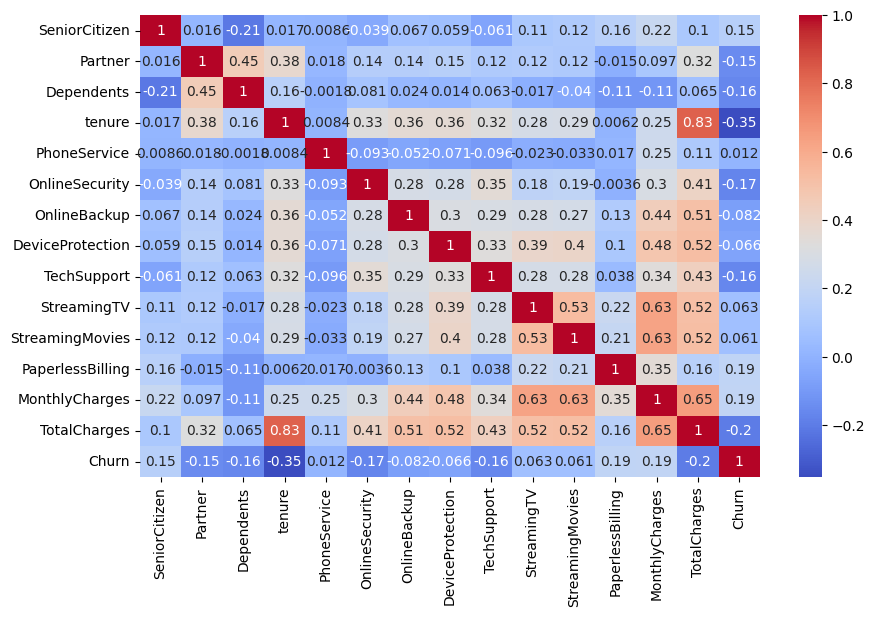

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

countplot  

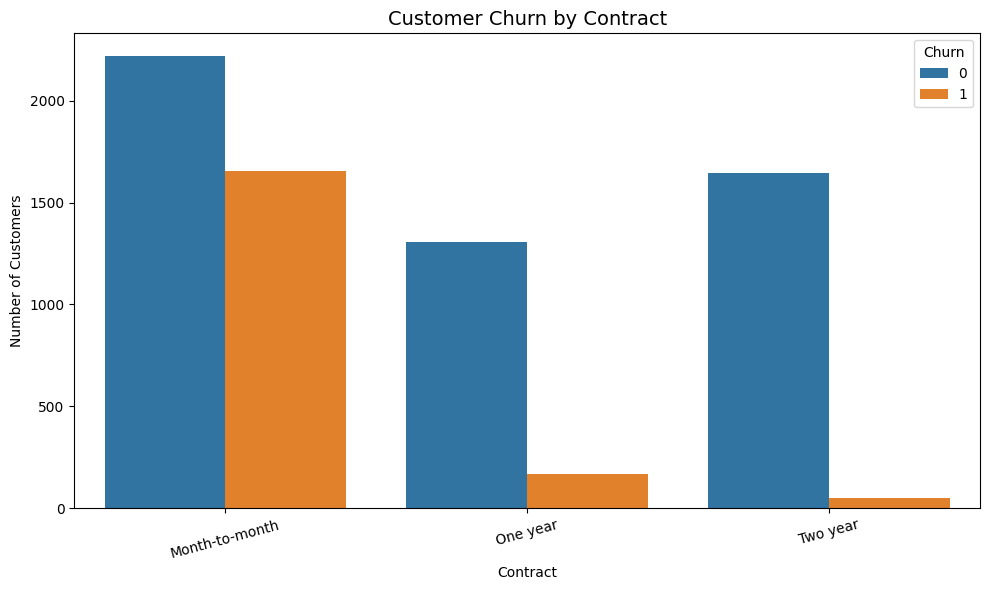

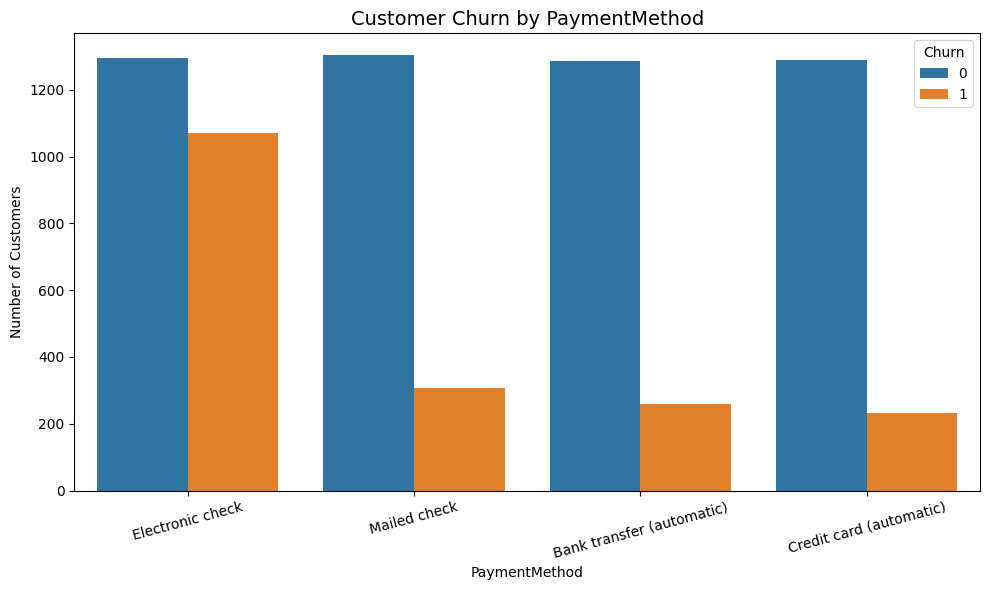

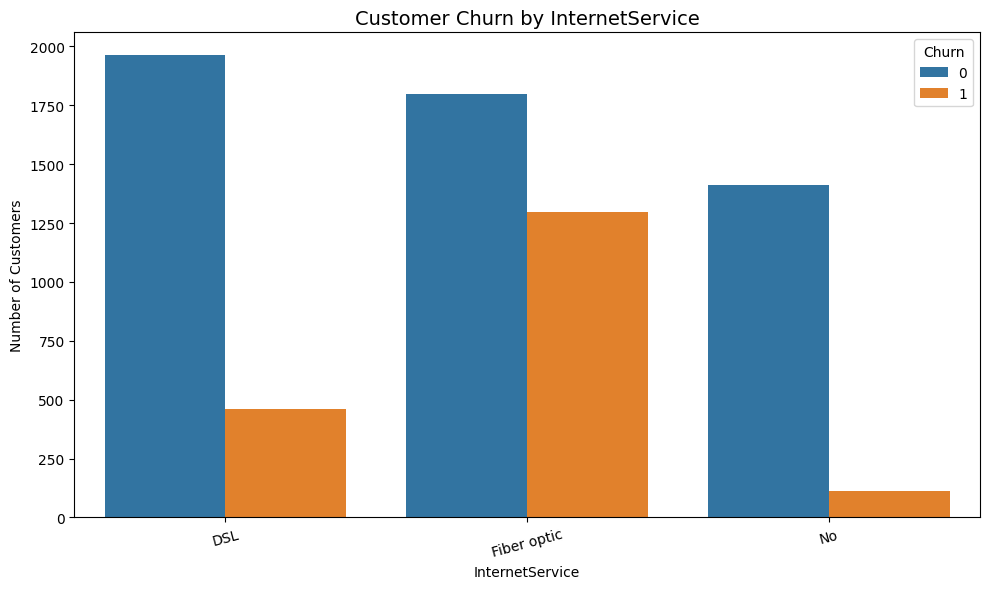

In [ ]:
categorical_features = ['Contract', 'PaymentMethod', 'InternetService']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=feature, hue='Churn', data=data)
    plt.title(f'Customer Churn by {feature}', fontsize=14)
    plt.xlabel(feature )
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

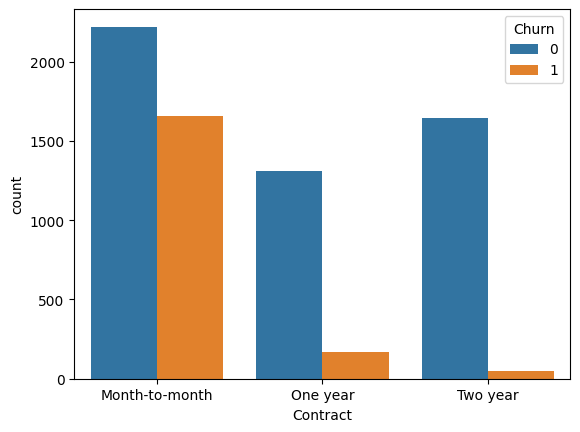

In [ ]:
sns.countplot(x='Contract', data=data, hue='Churn')
plt.show()

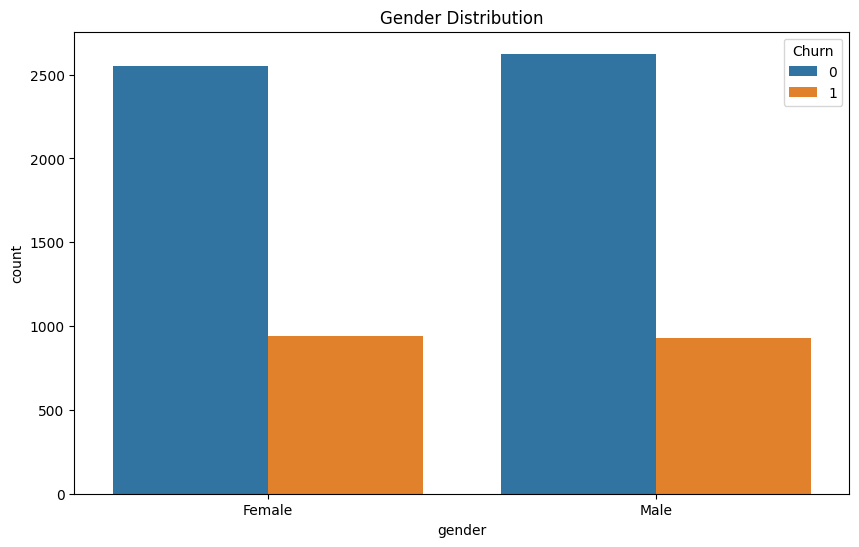

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=data,hue='Churn')
plt.title('Gender Distribution')
plt.show()

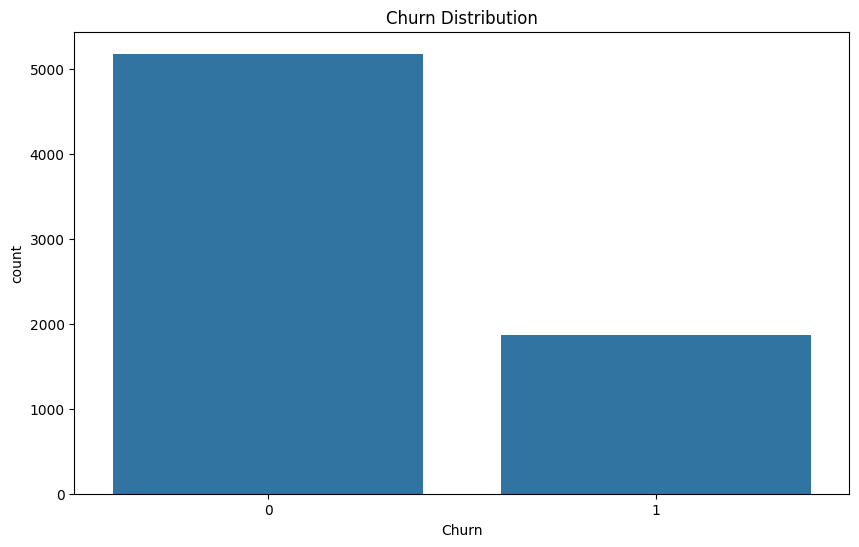

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Churn', data=data)
plt.title('Churn Distribution')
plt.show()

In [ ]:
data.describe(include='all').round(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.0,7043.0,7043.0,7043.0,7043.0,7043,7043,7043.0,...,7043.0,7043.0,7043.0,7043.0,7043,7043.0,7043,7043.0,7032.0,7043.0
unique,7043,2,NaN,NaN,NaN,NaN,NaN,3,3,NaN,...,NaN,NaN,NaN,NaN,3,NaN,4,NaN,NaN,NaN
top,3186-AJIEK,Male,NaN,NaN,NaN,NaN,NaN,No,Fiber optic,NaN,...,NaN,NaN,NaN,NaN,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,3555,NaN,NaN,NaN,NaN,NaN,3390,3096,NaN,...,NaN,NaN,NaN,NaN,3875,NaN,2365,NaN,NaN,NaN
mean,NaN,NaN,0.2,0.5,0.3,32.4,0.9,NaN,NaN,0.3,...,0.3,0.3,0.4,0.4,NaN,0.6,NaN,64.8,2283.3,0.3
std,NaN,NaN,0.4,0.5,0.5,24.6,0.3,NaN,NaN,0.5,...,0.5,0.5,0.5,0.5,NaN,0.5,NaN,30.1,2266.8,0.4
min,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,18.2,18.8,0.0
25%,NaN,NaN,0.0,0.0,0.0,9.0,1.0,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,35.5,401.4,0.0
50%,NaN,NaN,0.0,0.0,0.0,29.0,1.0,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,NaN,1.0,NaN,70.4,1397.5,0.0
75%,NaN,NaN,0.0,1.0,1.0,55.0,1.0,NaN,NaN,1.0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,89.8,3794.7,1.0


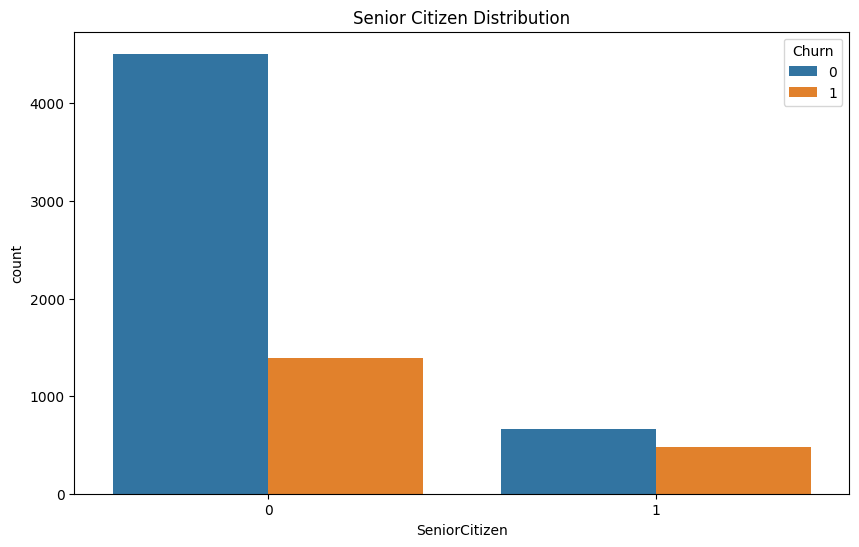

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='SeniorCitizen', data=data,hue='Churn')
plt.title('Senior Citizen Distribution')
plt.show()

Scatterplot

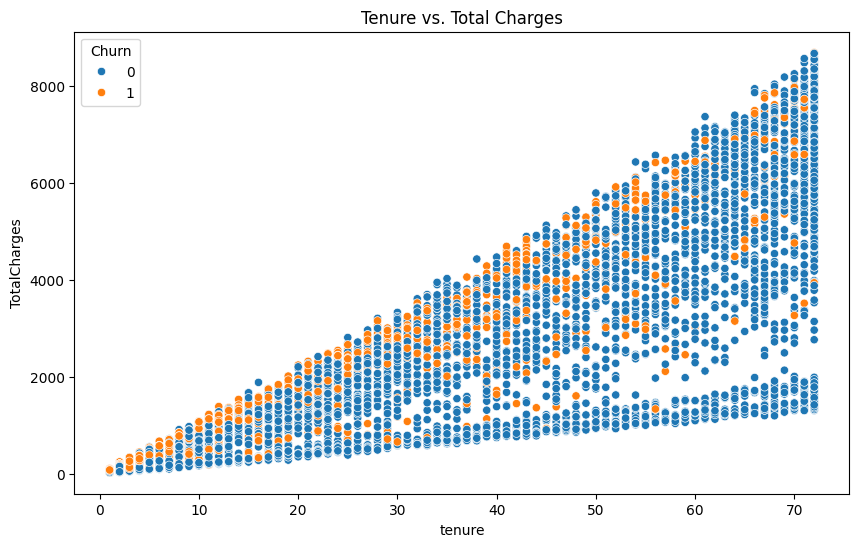

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='TotalCharges', data=data, hue='Churn')
plt.title('Tenure vs. Total Charges')
plt.show()

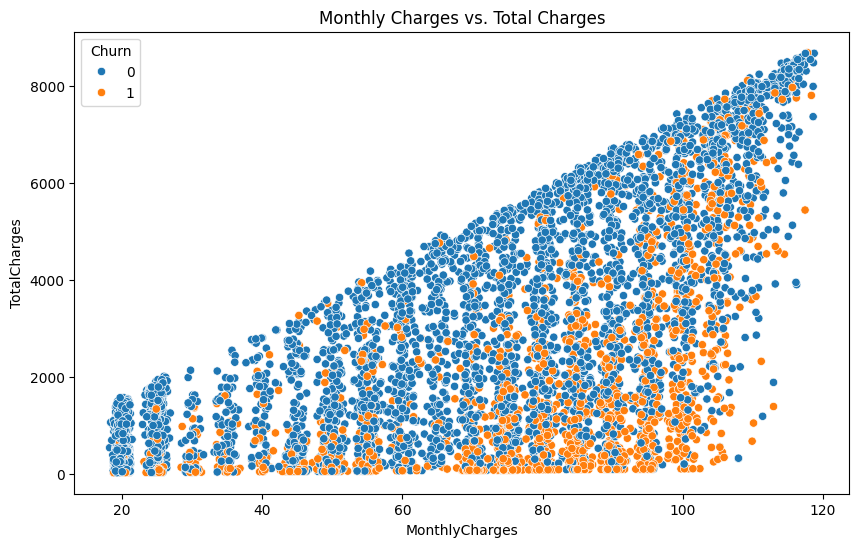

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', data=data, hue='Churn')
plt.title('Monthly Charges vs. Total Charges')
plt.show()

boxplot

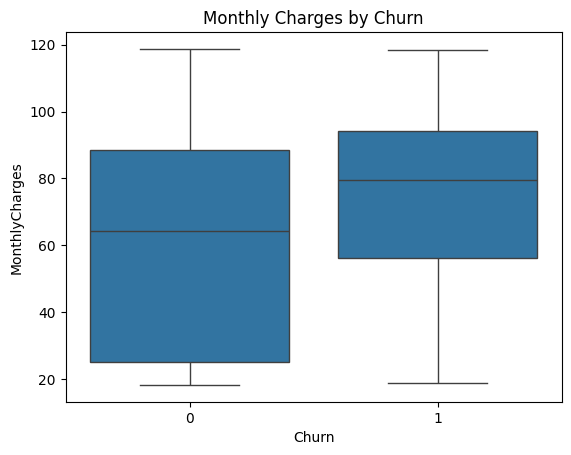

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title('Monthly Charges by Churn')
plt.show()

violinplot


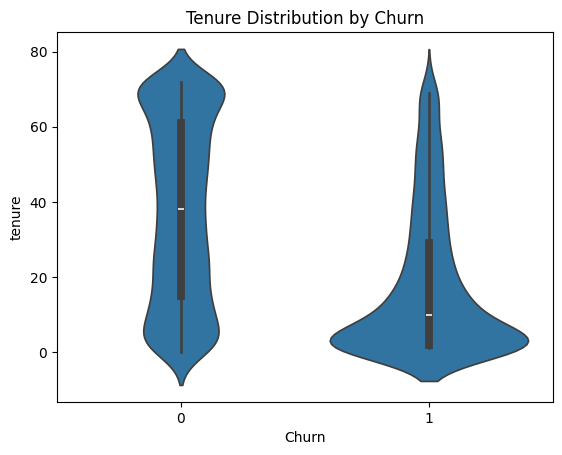

In [ ]:
sns.violinplot(x='Churn', y='tenure', data=data)
plt.title('Tenure Distribution by Churn')
plt.show()

pairplot



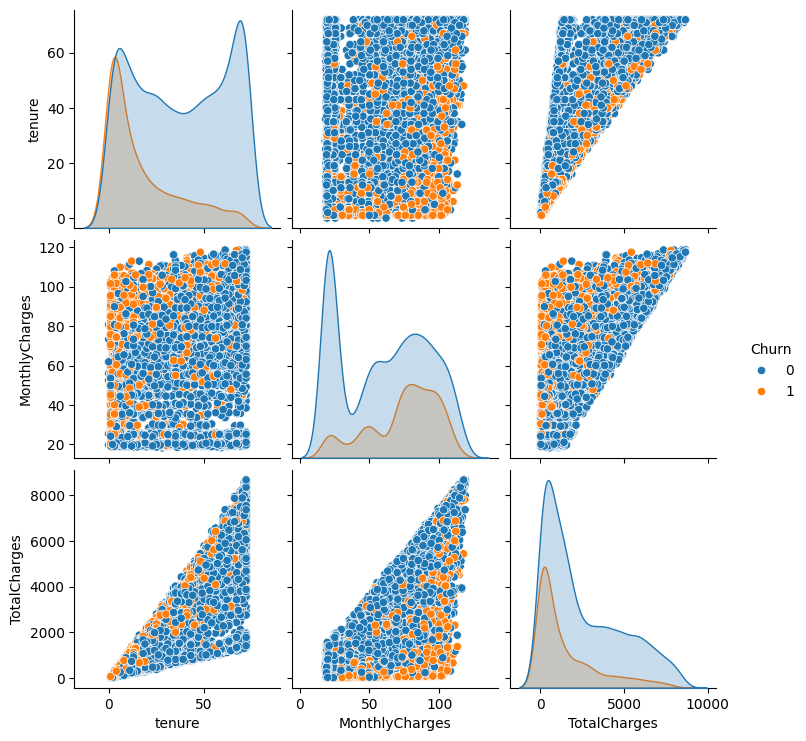

In [ ]:
data_subset = data[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
sns.pairplot(data_subset, hue='Churn')
plt.show()


Histplot

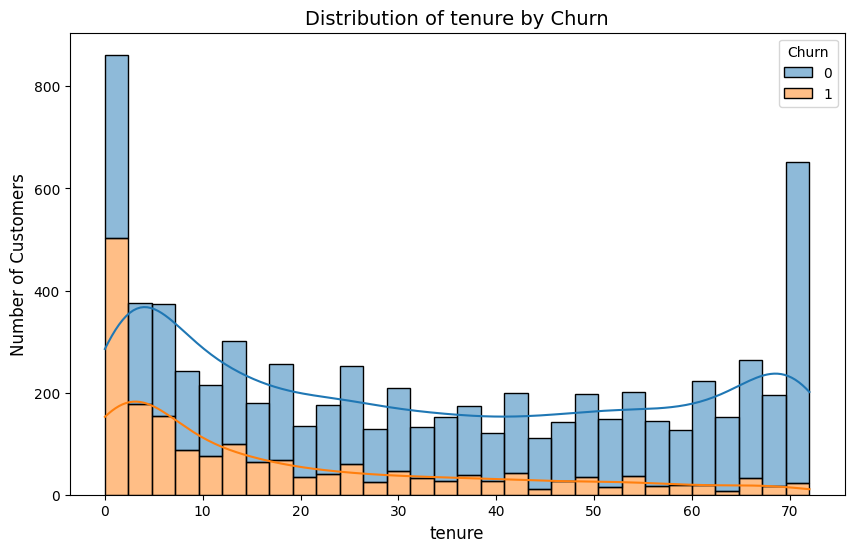

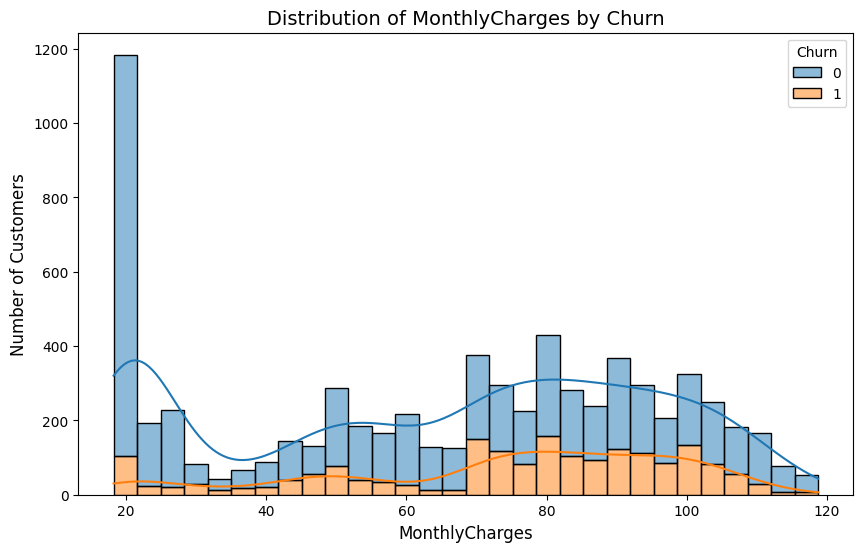

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges']
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data, x=feature, hue='Churn', multiple='stack', kde=True, bins=30)
    plt.title(f'Distribution of {feature} by Churn', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.show()

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


# **Preprocessing**

In [ ]:
#!pip install category_encoders
#import category_encoders as ce
#from sklearn.preprocessing import OneHotEncoder

In [ ]:
#categoryStrFeatures=[col for col in data.columns if data[col].dtype=='O']
#categoryStrFeatures

In [ ]:
#enco =ce.OneHotEncoder(cols=categoryStrFeatures)
#data=enco.fit_transform(data)

In [ ]:
data.discribe(include='all')

AttributeError: 'DataFrame' object has no attribute 'discribe'

In [ ]:
data.shape

(7043, 21)

In [ ]:
data=data.drop(['customerID'], axis=1)


In [ ]:
x=data.drop(['Churn'], axis=1)
y=data['Churn']


In [ ]:
#x=data.drop([[ 'Churn_1','churn_2']], axis=1)
#y=data['Churn_2']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = x_train.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  )


pip1 = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)), # Use with_mean=False after OneHotEncoding
    #('smote', SMOTE()),
    ('model', RandomForestClassifier())
])
model=pip1.fit(x_train, y_train)
model

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'MultipleLines', 'InternetService', 'Contract',
       'PaymentMethod'],
      dtype='object'))])),
                ('scaler', StandardScaler(with_mean=False)),
                ('model', RandomForestClassifier())])

In [ ]:
pridaction=model.predict(x_test)
pridaction.shape

(1409,)

In [ ]:
print('Train Accuracy:', model.score(x_train, y_train))
print('Test Accuracy:', model.score(x_test, y_test))

Train Accuracy: 0.9978700745473909
Test Accuracy: 0.7906316536550745


In [ ]:
print(classification_report(y_test, model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# LR  

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer

categorical_cols = x_train.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' )

pip = Pipeline([
     ('preprocessor', preprocessor),
     ('imputer', SimpleImputer(strategy='mean')), # Add SimpleImputer to handle NaNs
     ('scaler', StandardScaler()),
     ('model', LogisticRegression())
])
model_1=pip.fit(x_train, y_train)
model_1

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'MultipleLines', 'InternetService', 'Contract',
       'PaymentMethod'],
      dtype='object'))])),
                ('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', LogisticRegression())])

In [ ]:
print('Train Accuracy:', model_1.score(x_train, y_train))
print('Test Accuracy:', model_1.score(x_test, y_test))

Train Accuracy: 0.8061767838125665
Test Accuracy: 0.8069552874378992


In [ ]:
print(classification_report(y_test, model_1.predict(x_test)))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

